In [13]:
import matplotlib.pyplot as plt
from sklearn import datasets 
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('epl_player_stats_24_25.csv')


In [4]:
# Feature selection and target definition (similar to previous classification task)
features = ['Appearances', 'Minutes', 'Goals', 'Assists', 'Shots', 'Shots On Target', 
            'Touches', 'Passes', 'Successful Passes', 'Tackles', 'Interceptions', 
            'Clearances', 'Clean Sheets']
target = 'Position'  

In [5]:
positions_to_keep = ['DEF', 'MID', 'FWD', 'GKP']
df = df[df['Position'].isin(positions_to_keep)].dropna()

X = df[features]
y = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['tanh', 'relu'],
    'alpha': [0.0001, 0.001, 0.01]
}

In [9]:
mlp = MLPClassifier(max_iter=1000, random_state=42)
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model
grid_search.fit(X_train_scaled, y_train)

C:\Users\carlo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'activation': ['tanh', 'relu'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(50,), (100,), ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(50,)"


In [10]:
best_params = grid_search.best_params_
best_mlp = grid_search.best_estimator_

In [11]:
y_pred = best_mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definir el clasificador
mlp = MLPClassifier(max_iter=500, random_state=42)


In [16]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01]
}

In [20]:
print("Mejores hiperparámetros:", grid_search.fit(X_train, y_train))
print("Precisión en test set:", accuracy_score(y_test, grid_search.best_estimator_.predict(X_test)))

Mejores hiperparámetros: GridSearchCV(cv=5, estimator=MLPClassifier(max_iter=500, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.01],
                         'hidden_layer_sizes': [(50,), (100,), (50, 50)]},
             scoring='accuracy')
Precisión en test set: 0.8047337278106509


In [21]:
print("\nReporte completo:\n")
print(classification_report(y_test, grid_search.best_estimator_.predict(X_test)))


Reporte completo:

              precision    recall  f1-score   support

         DEF       0.90      0.80      0.85        66
         FWD       0.80      0.67      0.73        24
         GKP       0.83      0.77      0.80        13
         MID       0.73      0.86      0.79        66

    accuracy                           0.80       169
   macro avg       0.82      0.78      0.79       169
weighted avg       0.81      0.80      0.81       169



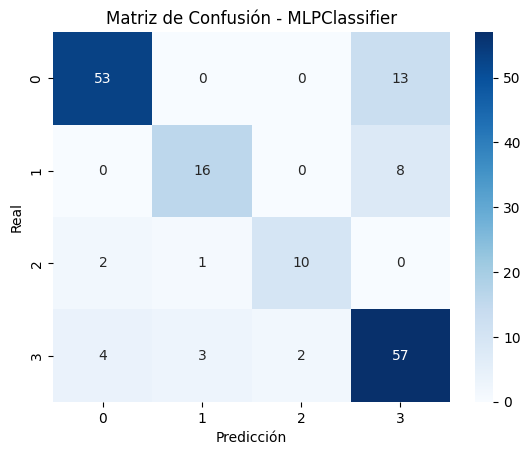

In [22]:
cm = confusion_matrix(y_test, grid_search.best_estimator_.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - MLPClassifier")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()